# Baseline model - Random Forest

In [1]:
# Cell 1 - Imports and Setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Add src/ to path to use project config
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'src'))
sys.path.insert(0, '../src')
from config import (
    MOLECULES, N_MOLECULES, RANDOM_SEED, STRONG_FEATURES,
    WEAK_FEATURES, BIOSIGNATURES, LOG_VMR_MIN, LOG_VMR_MAX,
    TRAIN_FRAC, VAL_FRAC, TEST_FRAC
)

print("All libraries loaded ✓")
print(f"Molecules: {MOLECULES}")

All libraries loaded ✓
Molecules: ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']


In [2]:
# Cell 2 - Load Data from inara_data/processed
## we need to remove npy files from inara_data folder. it should be under processed
DATA_DIR = os.path.join('..', 'inara_data/processed')

spectra     = np.load(os.path.join(DATA_DIR, 'spectra.npy'))
molecules   = np.load(os.path.join(DATA_DIR, 'molecules.npy'))
aux_params  = np.load(os.path.join(DATA_DIR, 'aux_params.npy'))
wavelengths = np.load(os.path.join(DATA_DIR, 'wavelengths.npy'))
params_df   = pd.read_csv(os.path.join(DATA_DIR, 'parameters_processed.csv'))

print(f"Spectra shape:     {spectra.shape}")
print(f"Molecules shape:   {molecules.shape}")
print(f"Aux params shape:  {aux_params.shape}")
print(f"Wavelengths shape: {wavelengths.shape}")
print(f"Params df shape:   {params_df.shape}")
print(f"\nInput channels:")
print(f"  Ch0 - Normalised SNR:    {spectra[:,0,:].shape}")
print(f"  Ch1 - Mean Subtracted:   {spectra[:,1,:].shape}")
print(f"  Ch2 - Log Transit Depth: {spectra[:,2,:].shape}")

Spectra shape:     (3503, 3, 4378)
Molecules shape:   (3503, 12)
Aux params shape:  (10000, 8)
Wavelengths shape: (4378,)
Params df shape:   (10000, 21)

Input channels:
  Ch0 - Normalised SNR:    (3503, 4378)
  Ch1 - Mean Subtracted:   (3503, 4378)
  Ch2 - Log Transit Depth: (3503, 4378)


In [3]:
"""

------------------------------------------------------------
SKIP THIS PART AND CONTINUE WITH ORIGINAL RECORDS
------------------------------------------------------------
# Cell 3 - Generated demo data ---
from download_inara import generate_demo

PROCESSED_DIR = os.path.join('..', 'inara_data', 'processed')

# Generating  samples 
print("Generating 20,000 synthetic samples...")
generate_demo(output_dir=PROCESSED_DIR, n_samples=20000)
print("Done ✓")
"""
#
print("Skip synthetic data generation.")

Skip synthetic data generation.


In [4]:
# Cell 4 - Loading dataset
PROCESSED_DIR = os.path.join('..', 'inara_data', 'processed')

spectra_full    = np.load(os.path.join(PROCESSED_DIR, 'spectra.npy'))
molecules_full  = np.load(os.path.join(PROCESSED_DIR, 'molecules.npy'))
aux_full        = np.load(os.path.join(PROCESSED_DIR, 'aux_params.npy'))
wavelengths_full= np.load(os.path.join(PROCESSED_DIR, 'wavelengths.npy'))

print(f"Full dataset:")
print(f"  Spectra shape:    {spectra_full.shape}")
print(f"  Molecules shape:  {molecules_full.shape}")
print(f"  Aux shape:        {aux_full.shape}")
print(f"  NaN in molecules: {np.isnan(molecules_full).sum()}")

Full dataset:
  Spectra shape:    (3503, 3, 4378)
  Molecules shape:  (3503, 12)
  Aux shape:        (10000, 8)
  NaN in molecules: 0


In [6]:
# Cell 5 - Prepare Features and Split Data
snr_ch   = spectra_full[:, 0, :]
meansub  = spectra_full[:, 1, :]

# Slice aux to match spectra size
aux_slice = aux_full[:len(spectra_full)]

# Combine spectral channels + auxiliary features
X_spec = np.hstack([snr_ch, meansub])
X_full = np.hstack([X_spec, aux_slice])
y_full = molecules_full

# Train/Val/Test split
rng  = np.random.default_rng(RANDOM_SEED)
idx  = rng.permutation(len(X_full))
n_train = int(len(X_full) * TRAIN_FRAC)
n_val   = int(len(X_full) * VAL_FRAC)

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

X_train, y_train = X_full[train_idx], y_full[train_idx]
X_val,   y_val   = X_full[val_idx],   y_full[val_idx]
X_test,  y_test  = X_full[test_idx],  y_full[test_idx]

print(f"Train: {X_train.shape[0]:,} samples")
print(f"Val:   {X_val.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")

Train: 2,452 samples
Val:   525 samples
Test:  526 samples
Features: 8764


In [7]:
# Cell 6 - Train Random Forest Baseline

print("Training Random Forest Baseline...")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)
print("\nTraining complete ✓")

Training Random Forest Baseline...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.5min



Training complete ✓


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.7min finished


In [8]:
# Cell 7 - Evaluate Random Forest on Test Set
y_pred = rf_model.predict(X_test)

print("="*60)
print("Random Forest Baseline — Per Molecule Results")
print("="*60)
print(f"{'Molecule':<8} {'RMSE':>8} {'MAE':>8} {'R2':>8} {'Difficulty'}")
print("-"*60)

rmse_list, mae_list, r2_list = [], [], []

for i, mol in enumerate(MOLECULES):
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    mae  = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2   = r2_score(y_test[:, i], y_pred[:, i])
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)
    
    if mol in STRONG_FEATURES:
        diff = 'Easy'
    elif mol in WEAK_FEATURES:
        diff = 'Hard'
    else:
        diff = 'Medium'
    
    print(f"{mol:<8} {rmse:>8.3f} {mae:>8.3f} {r2:>8.3f}  {diff}")

print("-"*60)
print(f"{'MEAN':<8} {np.mean(rmse_list):>8.3f} {np.mean(mae_list):>8.3f} {np.mean(r2_list):>8.3f}")
print("="*60)

Random Forest Baseline — Per Molecule Results
Molecule     RMSE      MAE       R2 Difficulty
------------------------------------------------------------
H2O         0.379    0.274    0.321  Easy
CO2         0.366    0.246    0.133  Easy
O2          0.327    0.219    0.402  Easy
O3          0.343    0.260    0.688  Easy
CH4         0.337    0.250    0.447  Medium
N2          0.395    0.269    0.010  Hard
N2O         0.435    0.333    0.007  Medium
CO          0.467    0.346    0.034  Medium
H2          0.506    0.352    0.006  Hard
H2S         0.317    0.230    0.543  Medium
SO2         0.551    0.416    0.231  Medium
NH3         0.456    0.335    0.044  Medium
------------------------------------------------------------
MEAN        0.407    0.294    0.239


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


## Visualization

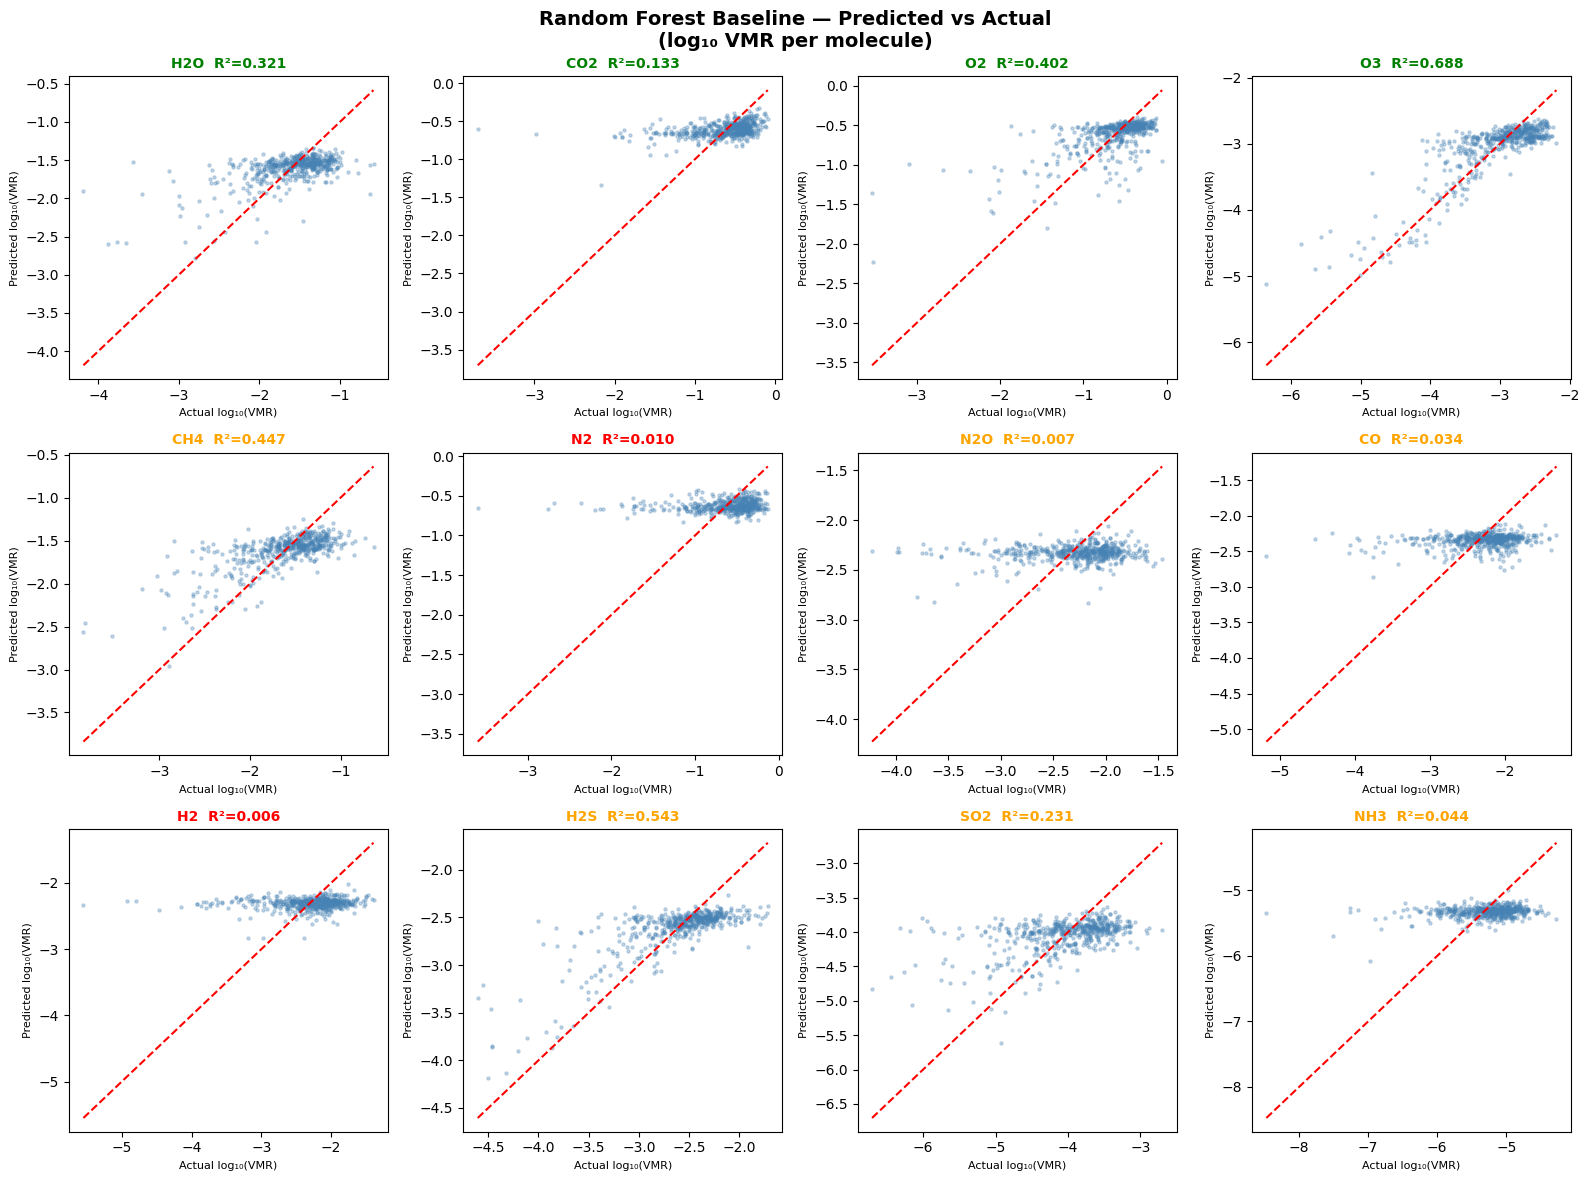

Plot saved to results/plots/rf_baseline_results.png ✓


In [9]:
# Cell 8 - Visualize Results
os.makedirs('../results/plots', exist_ok=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Random Forest Baseline — Predicted vs Actual\n(log₁₀ VMR per molecule)',
             fontsize=14, fontweight='bold')

for i, (mol, ax) in enumerate(zip(MOLECULES, axes.ravel())):
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.3, s=5, color='steelblue')
    mn = min(y_test[:, i].min(), y_pred[:, i].min())
    mx = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    
    if mol in STRONG_FEATURES:
        color = 'green'
    elif mol in WEAK_FEATURES:
        color = 'red'
    else:
        color = 'orange'
        
    ax.set_title(f'{mol}  R²={r2_list[i]:.3f}', 
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Actual log₁₀(VMR)', fontsize=8)
    ax.set_ylabel('Predicted log₁₀(VMR)', fontsize=8)

plt.tight_layout()
plt.savefig('../results/plots/rf_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/plots/rf_baseline_results.png ✓")

In [10]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Define molecule names (same order as dataset)
MOLECULE_NAMES = [
    "H2O", "CO2", "O2", "O3",
    "CH4", "N2", "N2O", "CO",
    "H2", "H2S", "SO2", "NH3"
]

def evaluate_model(y_true, y_pred, model_name="Model"):
    print(f"\n{'='*40}")
    print(f"{model_name} Evaluation")
    print(f"{'='*40}")

    # Overall metrics
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print("\nOverall Metrics:")
    print(f"R2   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")

    # Per molecule
    print("\nPer Molecule Metrics:")
    for i in range(y_true.shape[1]):
        r2_i = r2_score(y_true[:, i], y_pred[:, i])
        rmse_i = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae_i = mean_absolute_error(y_true[:, i], y_pred[:, i])

        name = MOLECULE_NAMES[i] if i < len(MOLECULE_NAMES) else f"Molecule {i}"

        print(f"{name:>4} → R2={r2_i:.3f}, RMSE={rmse_i:.3f}, MAE={mae_i:.3f}")

In [11]:
# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
evaluate_model(y_test, y_pred, model_name="Random Forest")


Random Forest Evaluation

Overall Metrics:
R2   : 0.2388
RMSE : 0.4131
MAE  : 0.2942

Per Molecule Metrics:
 H2O → R2=0.321, RMSE=0.379, MAE=0.274
 CO2 → R2=0.133, RMSE=0.366, MAE=0.246
  O2 → R2=0.402, RMSE=0.327, MAE=0.219
  O3 → R2=0.688, RMSE=0.343, MAE=0.260
 CH4 → R2=0.447, RMSE=0.337, MAE=0.250
  N2 → R2=0.010, RMSE=0.395, MAE=0.269
 N2O → R2=0.007, RMSE=0.435, MAE=0.333
  CO → R2=0.034, RMSE=0.467, MAE=0.346
  H2 → R2=0.006, RMSE=0.506, MAE=0.352
 H2S → R2=0.543, RMSE=0.317, MAE=0.230
 SO2 → R2=0.231, RMSE=0.551, MAE=0.416
 NH3 → R2=0.044, RMSE=0.456, MAE=0.335


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


## Optional

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree

sns.set(style="whitegrid")

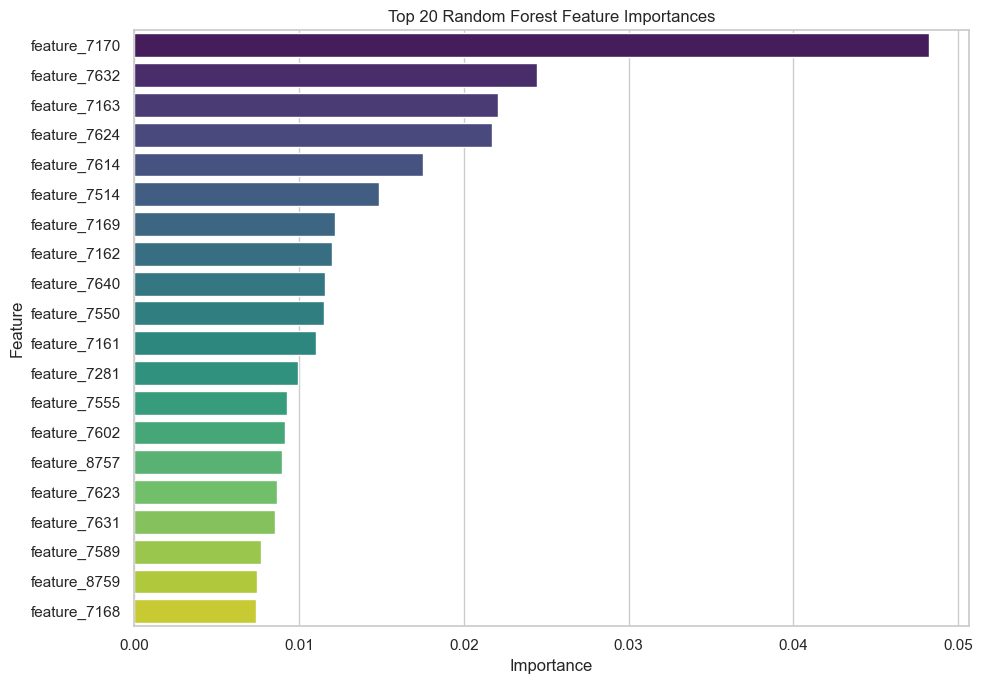

In [13]:
# Visualize feature importance from the trained Random Forest

if "rf_model" not in globals():
    raise RuntimeError("rf_model is not available in the notebook. Train the model first.")

importances = rf_model.feature_importances_

feature_names = [f"feature_{i}" for i in range(len(importances))]
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_df.head(20), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

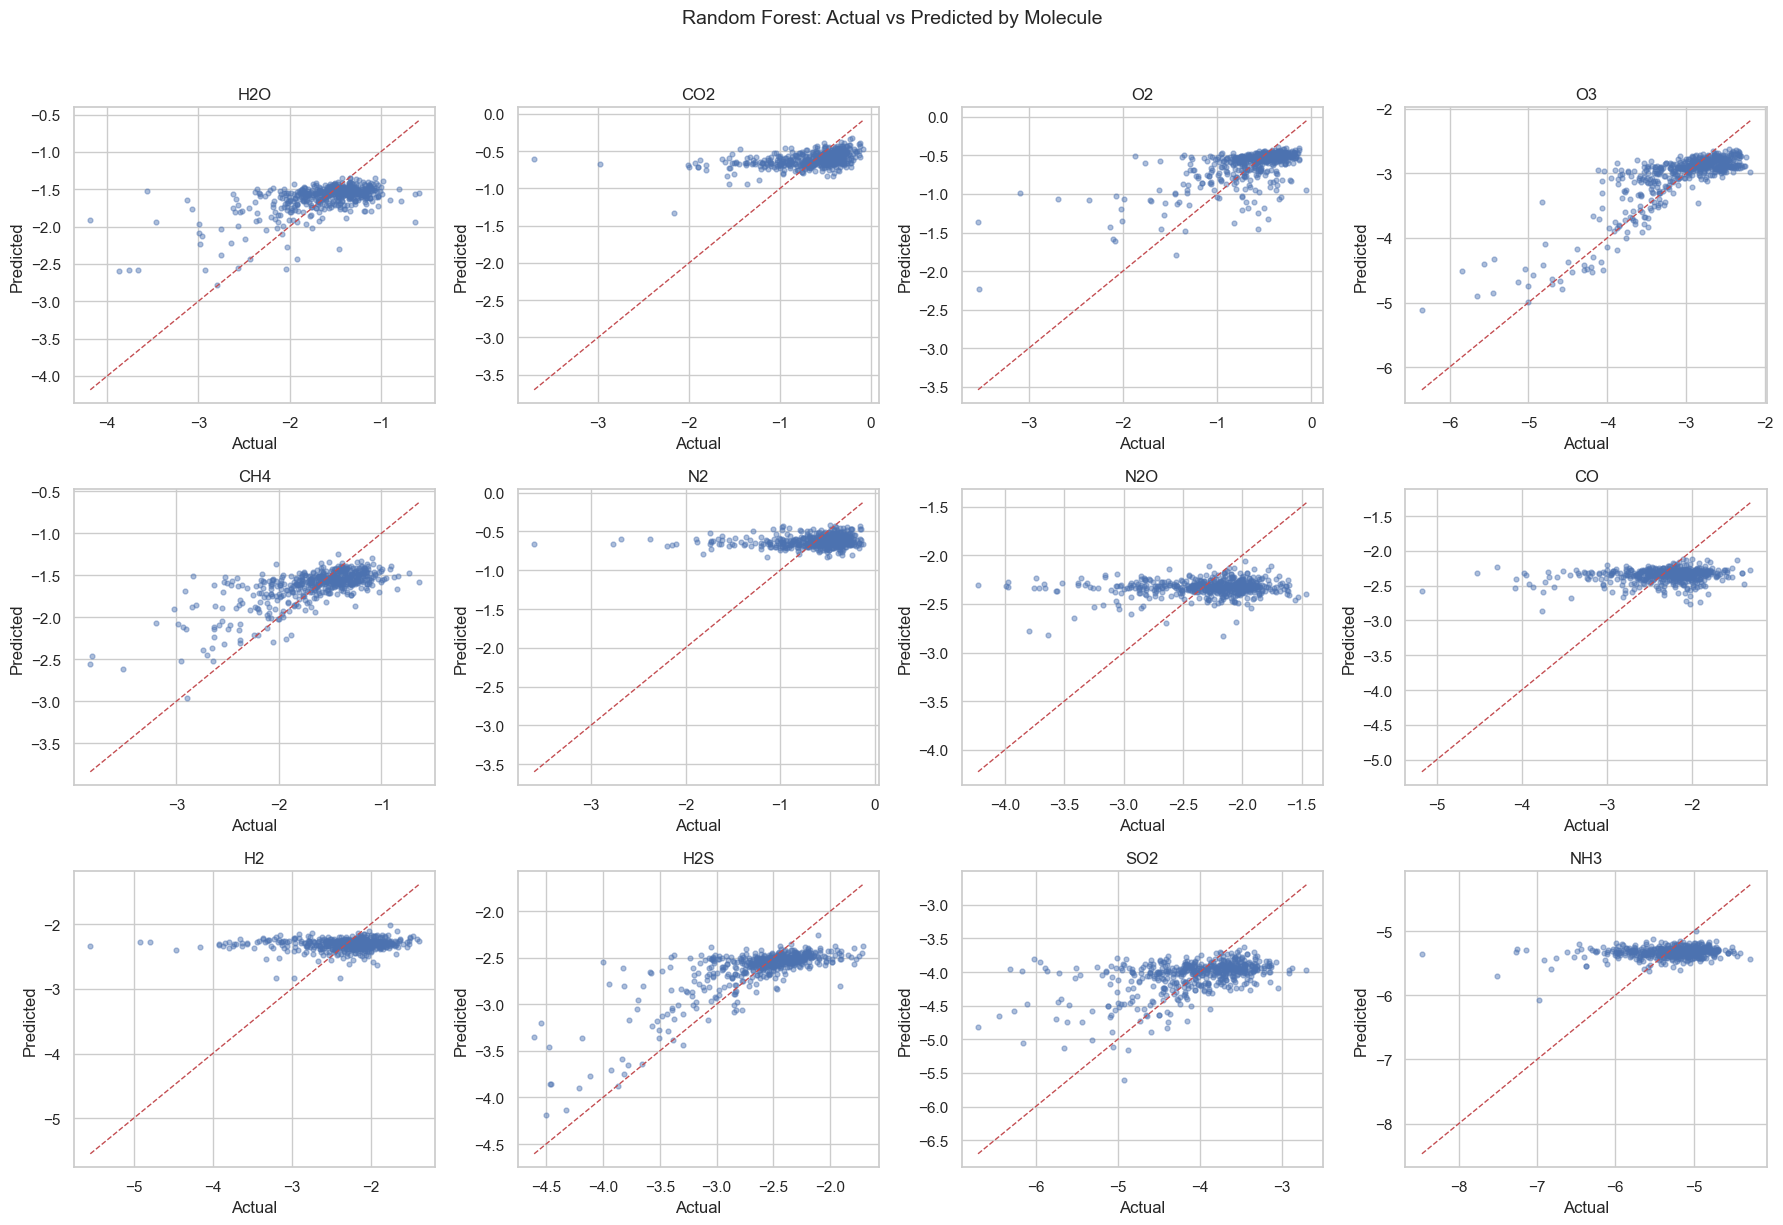

In [14]:
# Actual vs predicted plots for each molecule

molecules = ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, mol in enumerate(molecules):
    ax = axes[i]
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.45, s=12)
    mn = min(y_test[:, i].min(), y_pred[:, i].min())
    mx = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1)
    ax.set_title(mol)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.suptitle("Random Forest: Actual vs Predicted by Molecule", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

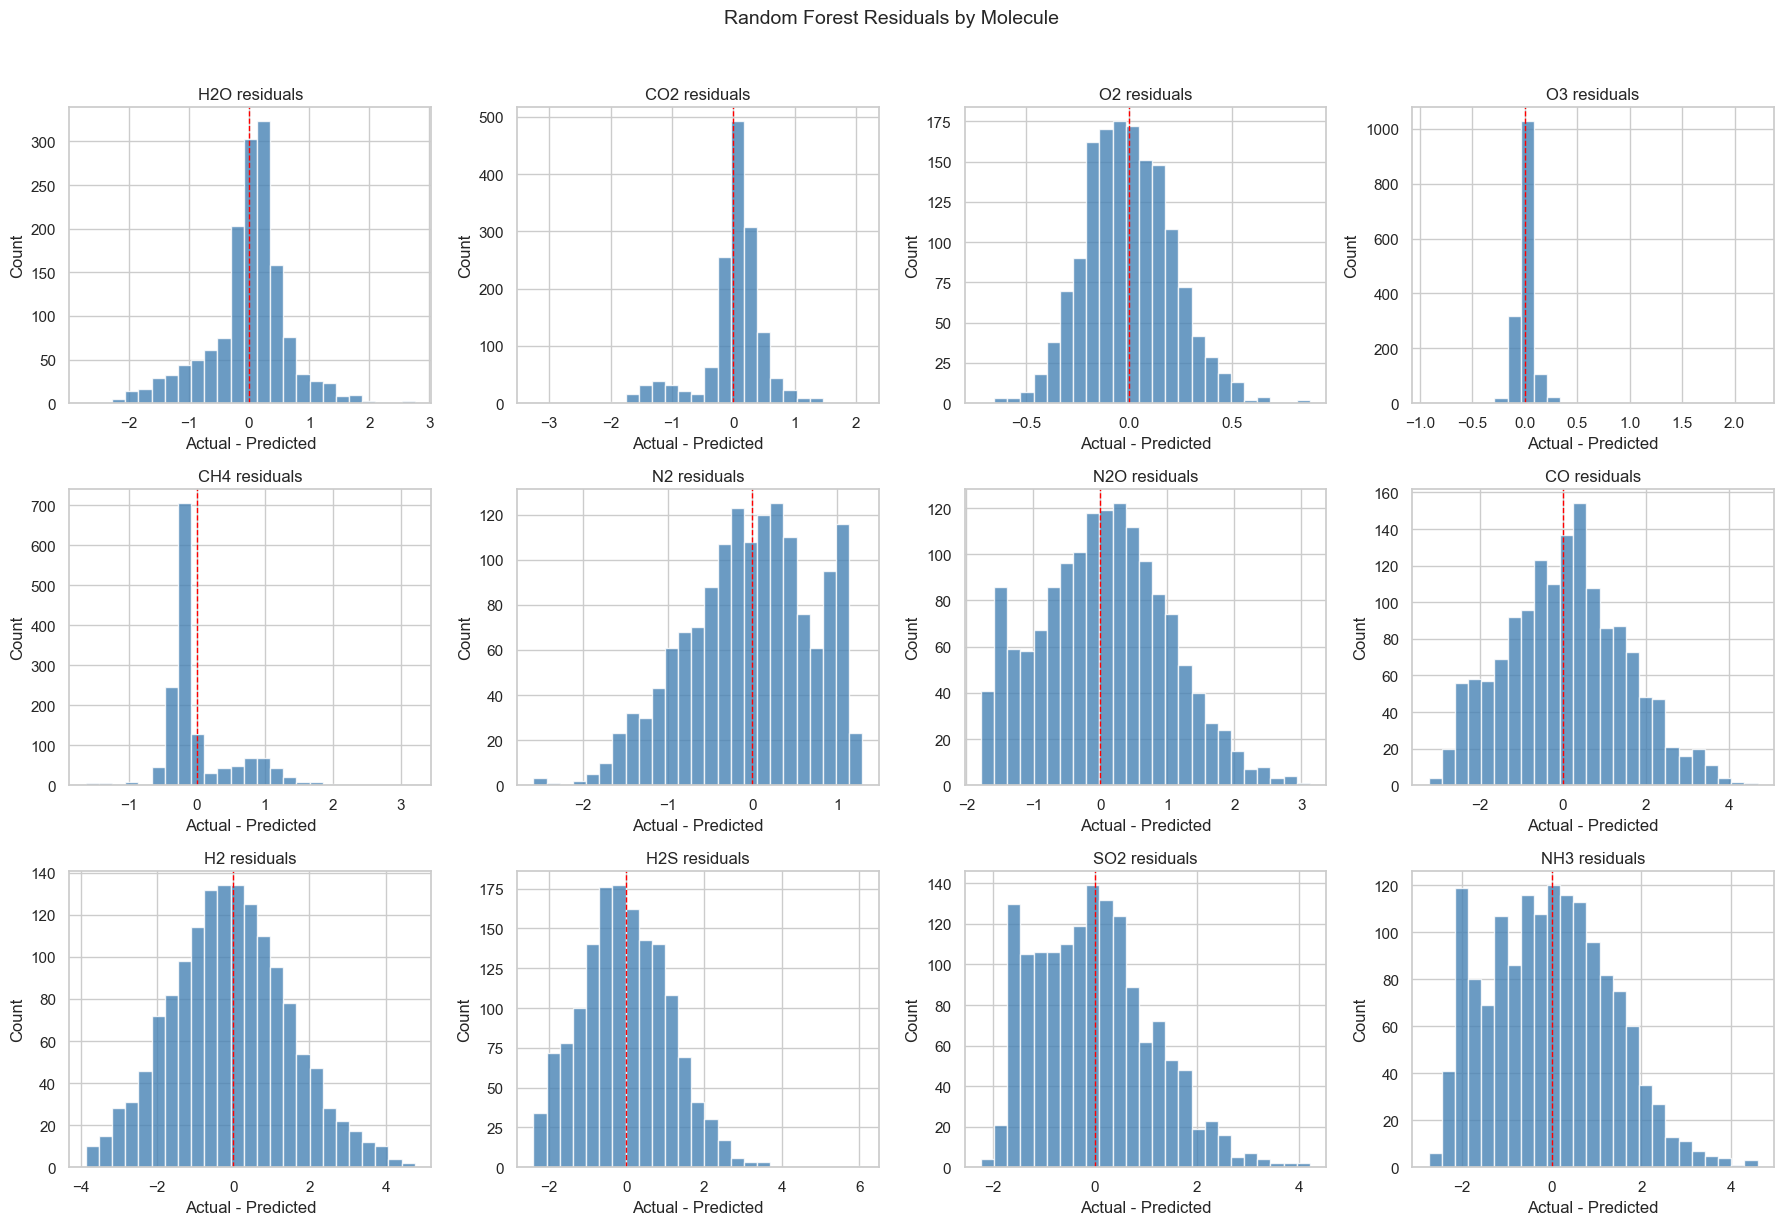

In [ ]:
# Residual histograms

residuals = y_test - y_pred

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, mol in enumerate(molecules):
    ax = axes[i]
    ax.hist(residuals[:, i], bins=25, alpha=0.8, color="steelblue", edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", lw=1)
    ax.set_title(f"{mol} residuals")
    ax.set_xlabel("Actual - Predicted")
    ax.set_ylabel("Count")

plt.suptitle("Random Forest Residuals by Molecule", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

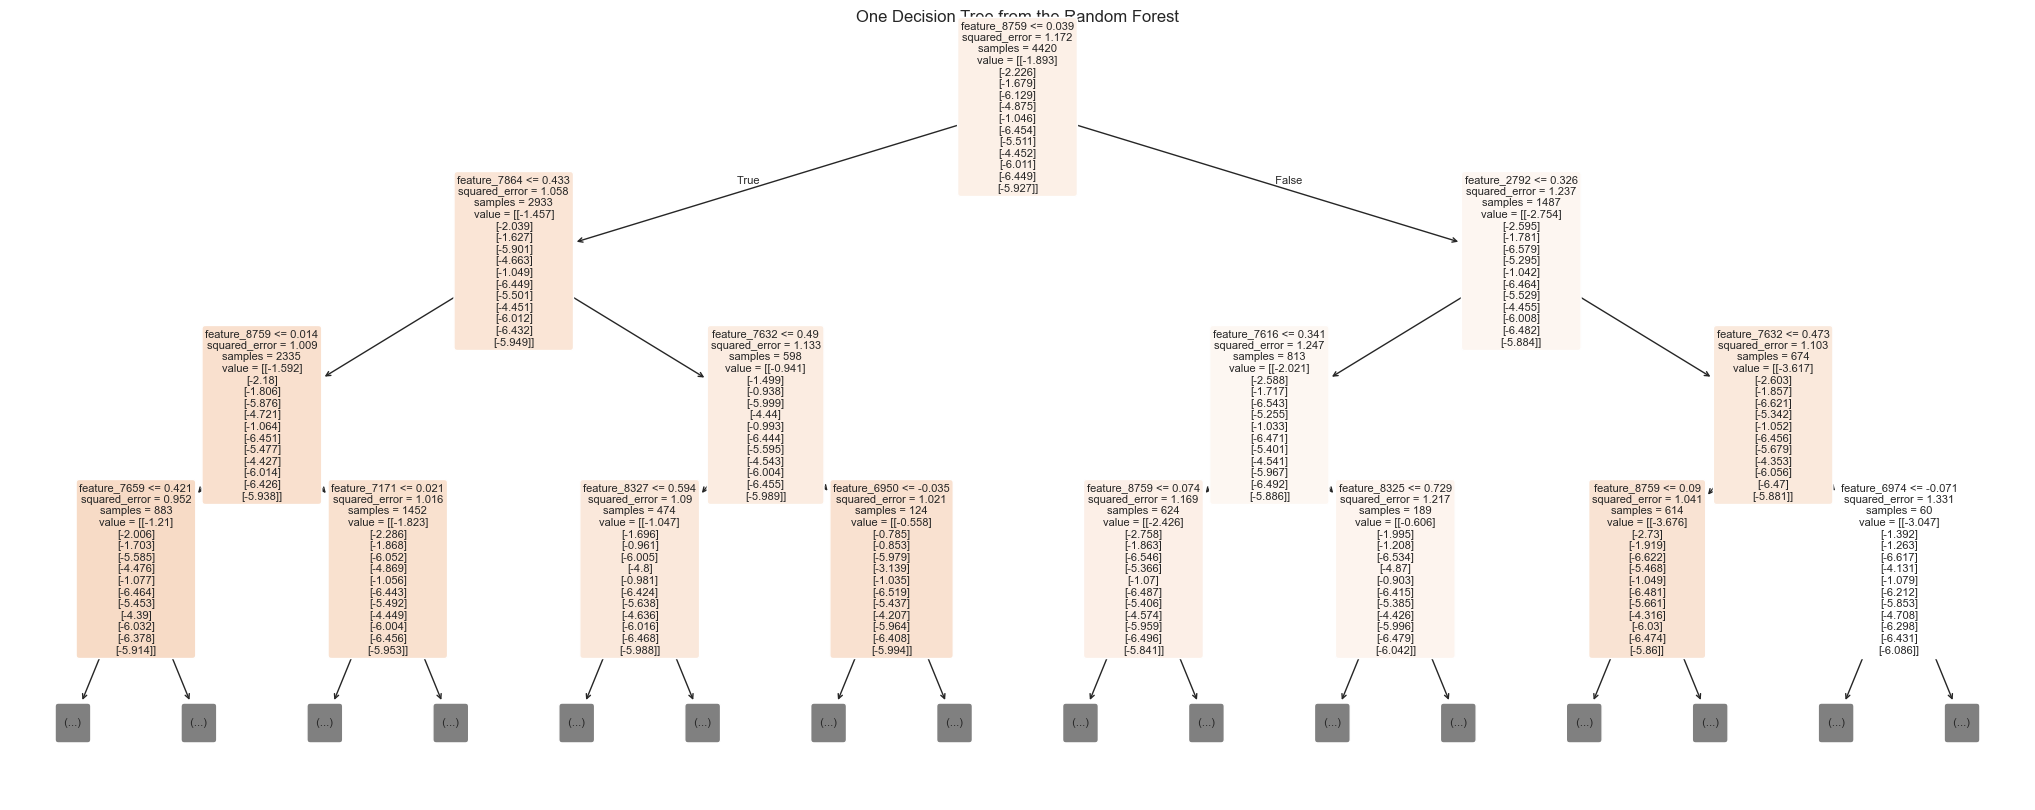

In [ ]:
# Optional: visualize one tree from the forest
# Note: keep max_depth small, otherwise the plot becomes a forest of confusion.

tree = rf_model.estimators_[0]

plt.figure(figsize=(26, 10))
plot_tree(
    tree,
    max_depth=3,
    filled=True,
    rounded=True,
    feature_names=feature_names,
    fontsize=8
)
plt.title("One Decision Tree from the Random Forest")
plt.show()